In [1]:
import os
import ctypes
import sys
from pathlib import Path

# --- 1. PATH native library setup ---
root = Path.cwd()

if sys.platform.startswith('linux'):
    lib_dir = root / 'pathlib' / 'lib_lnx'
    lib_name = 'pathwrap.so'
    path_lib_name = 'libpath50.so'
elif sys.platform == 'darwin':
    lib_dir = root / 'pathlib' / 'lib_osx'
    lib_name = 'pathwrap.dylib'
    path_lib_name = 'libpath50.dylib'
elif sys.platform.startswith('win'):
    lib_dir = root / 'pathlib' / 'lib_win'
    lib_name = 'pathwrap.dll'
    path_lib_name = 'libpath50.dll'
else:
    lib_dir = root / 'pathlib' / 'lib_lnx'
    lib_name = 'pathwrap.so'
    path_lib_name = 'libpath50.so'

pathwrap_path = root / lib_name

if not pathwrap_path.exists():
    print('Missing pathwrap library:', pathwrap_path)
    print('Build it with:')
    print('  gcc -shared -fPIC -Ipathlib/include -Ipathlib/examples/C -o pathwrap.so \\')
    print('    pathwrap.c pathlib/examples/C/Standalone_Path.c \\')
    print('    -Lpathlib/lib_lnx -lpath50 -lm -ldl')

# Preload PATH shared library BEFORE anything tries to use pathwrap
if lib_dir.exists():
    ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    if str(lib_dir) not in ld_path:
        os.environ['LD_LIBRARY_PATH'] = f"{lib_dir}:{ld_path}" if ld_path else str(lib_dir)

if not os.environ.get('PATH_LICENSE_STRING'):
    os.environ['PATH_LICENSE_STRING'] = '1259252040&Courtesy&&&USR&GEN2035&5_1_2026&1000&PATH&GEN&31_12_2035&0_0_0&6000&0_0'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from GridWorld import GridWorldEnv
from SRQagent import SRQAgent

In [3]:
def train_experiment(n_episodes=1000, p_env=0.8, pathwrap_path=None, checkpoint_interval=100, checkpoint_dir="checkpoints"):

    env = GridWorldEnv(p=p_env)
    
    pathwrap_path = pathwrap_path or str(globals().get("pathwrap_path", "pathwrap.so"))
    
    # Get environment dimensions
    num_agents = 2
    num_actions = len(env.action_space)
    
    # Initialize Agents with correct parameters
    agents = [
        SRQAgent(
            agent_id=0, 
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            alpha=0.1,
            gamma=0.9,
            decay_rate=0.999,  
            pathwrap_path=pathwrap_path
        ),
        SRQAgent(
            agent_id=1,
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            alpha=0.1,
            gamma=0.9,
            decay_rate=0.999,
            pathwrap_path=pathwrap_path
        )
    ]
    
    history_rewards = [[], []]
    checkpoint_path = Path(checkpoint_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)
    
    print(f"Starting Training: {n_episodes} Episodes, p={p_env}")
    
    for ep in tqdm(range(n_episodes)):
        obs = env.reset()
        done = False
        ep_rewards = [0, 0]
        
        while not done:
            actions = [ag.act(obs) for ag in agents]
            next_obs, rewards, done, _ = env.step(actions)
            
            for ag in agents:
                ag.update(obs, actions, rewards, next_obs)
                
            obs = next_obs
            ep_rewards[0] += rewards[0]
            ep_rewards[1] += rewards[1]
            
        history_rewards[0].append(ep_rewards[0])
        history_rewards[1].append(ep_rewards[1])
        if (ep + 1) % checkpoint_interval == 0:
            for idx, ag in enumerate(agents):
                ag.save_q_table(checkpoint_path / f"srq_agent{idx}_ep{ep + 1}.pkl")
        print(f"Episode {ep + 1} reward: {ep_rewards}")
        
        for ag in agents:
            ag.decay_parameters()
            
    return history_rewards

rewards_data = train_experiment(n_episodes=1000, p_env=0.8)

Loading PATH wrapper from /homes/jhl323/SRE-DQN/bimatrix_game/pathwrap.so...
PATH Solver Ready.
Loading PATH wrapper from /homes/jhl323/SRE-DQN/bimatrix_game/pathwrap.so...
PATH Solver Ready.
Starting Training: 1000 Episodes, p=0.8


  0%|          | 1/1000 [00:03<1:03:22,  3.81s/it]

Episode 1 reward: [-16, -28]


  0%|          | 2/1000 [00:06<48:09,  2.90s/it]  

Episode 2 reward: [-17, -9]


...

Episode 998 reward: [-105, -108]


100%|█████████▉| 999/1000 [1:17:06<00:03,  3.18s/it]

Episode 999 reward: [92, 93]


100%|██████████| 1000/1000 [1:17:12<00:00,  4.63s/it]

Episode 1000 reward: [82, 89]


In [4]:
import pickle

# Save reward histories
with open("history_rewards.pkl", "wb") as f:
    pickle.dump(rewards_data, f, protocol=pickle.HIGHEST_PROTOCOL)

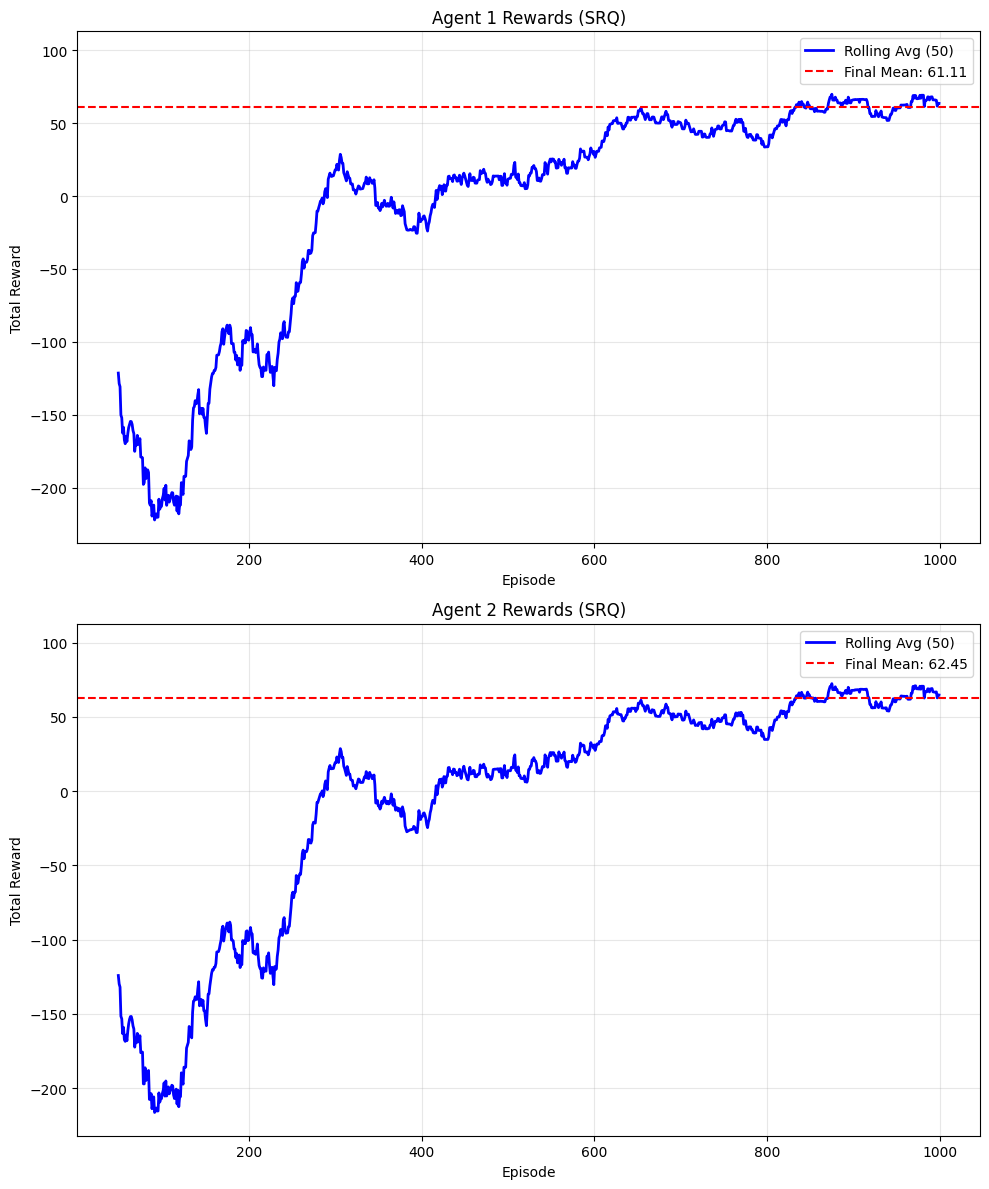

In [8]:
def plot_results(rewards, window=50, out_path="results.png"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))
    
    for agent_id in [0, 1]:
        ax = axes[agent_id]
        data = rewards[agent_id]
        
        
        # Rolling Average
        rolling_mean = np.convolve(data, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(data)), rolling_mean, linewidth=2, color='blue', label=f'Rolling Avg ({window})')
        
        # Statistics (Last 100 episodes)
        last_100 = data[-100:]
        mean_val = np.mean(last_100)
        std_val = np.std(last_100)
        
        ax.axhline(mean_val, color='red', linestyle='--', label=f'Final Mean: {mean_val:.2f}')
        min_y = float(np.min(rolling_mean))
        max_y = float(np.max(data))
        pad = 0.05 * (max_y - min_y) if max_y > min_y else 1.0
        ax.set_ylim(min_y - pad, max_y + pad)
        
        ax.set_title(f"Agent {agent_id+1} Rewards (SRQ)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")  # save to file
    plt.show()

plot_results(rewards_data)

In [ ]:
from DeepSRQagent import DeepSRQAgent

def _flatten_obs(obs):
    return np.array([coord for pos in obs for coord in pos], dtype=np.float32)

def train_deep_experiment(n_episodes=100, p_env=0.8, pathwrap_path=None, batch_size=32, target_update=10, checkpoint_interval=100, checkpoint_dir="checkpoints_deep"):

    env = GridWorldEnv(p=p_env)
    pathwrap_path = pathwrap_path or str(globals().get("pathwrap_path", "pathwrap.so"))

    num_agents = 2
    num_actions = len(env.action_space)
    obs_dim = len(_flatten_obs(env.reset()))

    agents = [
        DeepSRQAgent(
            agent_id=0,
            obs_dim=obs_dim,
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            lr=1e-3,
            gamma=0.9,
            decay_rate=0.999,
            buffer_size=10000,
            pathwrap_path=pathwrap_path
        ),
        DeepSRQAgent(
            agent_id=1,
            obs_dim=obs_dim,
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            lr=1e-3,
            gamma=0.9,
            decay_rate=0.999,
            buffer_size=10000,
            pathwrap_path=pathwrap_path
        )
    ]

    history_rewards = [[], []]
    checkpoint_path = Path(checkpoint_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)

    print(f"Starting Deep Training: {n_episodes} Episodes, p={p_env}")

    for ep in tqdm(range(n_episodes)):
        obs = env.reset()
        obs_vec = _flatten_obs(obs)
        done = False
        ep_rewards = [0, 0]

        while not done:
            actions = [ag.act(obs_vec) for ag in agents]
            next_obs, rewards, done, _ = env.step(actions)
            next_obs_vec = _flatten_obs(next_obs)

            for ag in agents:
                ag.replay_buffer.push(obs_vec, actions, rewards, next_obs_vec, done)
                ag.train_step(batch_size=batch_size)

            obs_vec = next_obs_vec
            ep_rewards[0] += rewards[0]
            ep_rewards[1] += rewards[1]

        history_rewards[0].append(ep_rewards[0])
        history_rewards[1].append(ep_rewards[1])
        if (ep + 1) % checkpoint_interval == 0:
            for idx, ag in enumerate(agents):
                ag.save_checkpoint(checkpoint_path / f"deep_agent{idx}_ep{ep + 1}.pt")

        if (ep + 1) % target_update == 0:
            for ag in agents:
                ag.update_target_network()

        for ag in agents:
            ag.epsilon_explore *= ag.decay_rate
            ag.epsilon_robust *= ag.decay_rate

    return history_rewards

deep_rewards = train_deep_experiment(n_episodes=100, p_env=0.8, pathwrap_path=pathwrap_path)
plot_results(deep_rewards, out_path="results_deep.png")


In [ ]:
import pickle

# Save reward histories
with open("history_rewards_deep.pkl", "wb") as f:
    pickle.dump(deep_rewards, f, protocol=pickle.HIGHEST_PROTOCOL)